# Exploratory Analysis

In [2]:
#Importing packages and setting parameters for initial analysis
import geopandas as gpd
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../src')
from ntl_functions import plot_NASA_NTL, filter_dataset_by_bounding_box



In [3]:
#Load Somaliland Boundary Shapefiles

gdf = gpd.read_file(
    "../data/Combined_Datasets/gadm41_SOM_1.json.zip"
)
#Somaliland SHP File
somaliland_shp = gdf[gdf["HASC_1"].isin(["SO.AW", "SO.WO", "SO.TO", "SO.SA", "SO.SO"])]

#Phillip Somaliland_SHP
somaliland_shp_berbera = gpd.read_file(
    "../data/Combined_Datasets/Somaliland_with_berbera/somaliland_with_berbera.shp"
)

somaliland_shp_expanded = (
    somaliland_shp
    .to_crs(epsg=32638)
    .dissolve()
    .buffer(300)
    .to_crs(epsg=4326)
    .to_frame("geometry")
    .reset_index(drop=True)
)

In [4]:
SL_normal = xr.open_dataset("../data/NTL_Data_A4/20251215_SL_VNP46A4_EY_2012_24.nc")
SL_berbera = xr.open_dataset("../data/NTL_Data_A4/141225_SL_Berbera_VNP46A4_EY_2012_24.nc")
SL_expanded = xr.open_dataset("../data/NTL_Data_A4/20251215_SL_Expanded_VNP46A4_EY_2012_24.nc")


#Monthly Data.
SL_month = xr.open_dataset("../data/NTL_Data_A4/141225_SL_VNP46A3_EM_2012_2017.nc")
SL_qual = xr.open_dataset("../data/NTL_Data_A4/141225_Qual_SL_VNP46A3_EM_2012_2017.nc")
SL_num = xr.open_dataset("../data/NTL_Data_A4/141225_Num_SL_VNP46A3_EM_2012_2017.nc")



Exploring the extent and values of the VNP46A4 Data for Somaliland.

In [4]:
print("SL Normal", list(SL_normal.data_vars))
print("SL Berbera", list(SL_berbera.data_vars))
print("SL Expanded", list(SL_expanded.data_vars))

SL Normal ['NearNadir_Composite_Snow_Free']
SL Berbera ['NearNadir_Composite_Snow_Free']
SL Expanded ['NearNadir_Composite_Snow_Free']


In [ ]:
print(SL_expanded.coords)
print(SL_expanded.rio.resolution())
print(SL_expanded.rio.bounds())

Coordinates:
  * time     (time) datetime64[ns] 96B 2012-01-01 2013-01-01 ... 2023-01-01
  * y        (y) float64 7kB 11.51 11.51 11.51 11.5 ... 7.998 7.994 7.99 7.985
  * x        (x) float64 12kB 42.7 42.71 42.71 42.71 ... 49.07 49.07 49.08 49.08
None
(0.004166666666666669, -0.004166717529296873)
(42.7001220703125, 7.983308715820315, 49.083455403645836, 11.516685180664064)


In [ ]:
#Showing the total number of pixels in Somaliland, the number of pixels with light detected each year, and the total radiance each year. 
non_zero_pixels = []
total_pixels = []
radiance_data = []
for year in range(2012, 2024):
    total_pixels.append(round((SL_expanded["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01")).count().item(), 1))
    non_zero_pixels.append(round((SL_expanded["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01") > 0).sum().item(), 1))
    radiance_data.append(round((SL_expanded["NearNadir_Composite_Snow_Free"].sel(time=f"{year}-01-01")).sum().item(), 1))

df = pd.DataFrame({
    "year": list(range(2012, 2024)),
    "total_pixels": total_pixels,
    "non_zero_pixels": non_zero_pixels,
    "radiance_data": radiance_data
})
print(df)

    year  total_pixels  non_zero_pixels  radiance_data
0   2012        810821              570         1727.9
1   2013        810821              581         1788.3
2   2014        810821              668         1960.7
3   2015        810821              756         2169.9
4   2016        810821              762         2335.4
5   2017        810821              887         2746.2
6   2018        810821             1056         3529.0
7   2019        810821             1144         4337.9
8   2020        810821             1328         5667.6
9   2021        810821             1775         7854.1
10  2022        810821             2444         9813.1
11  2023        810821             2593        10856.4


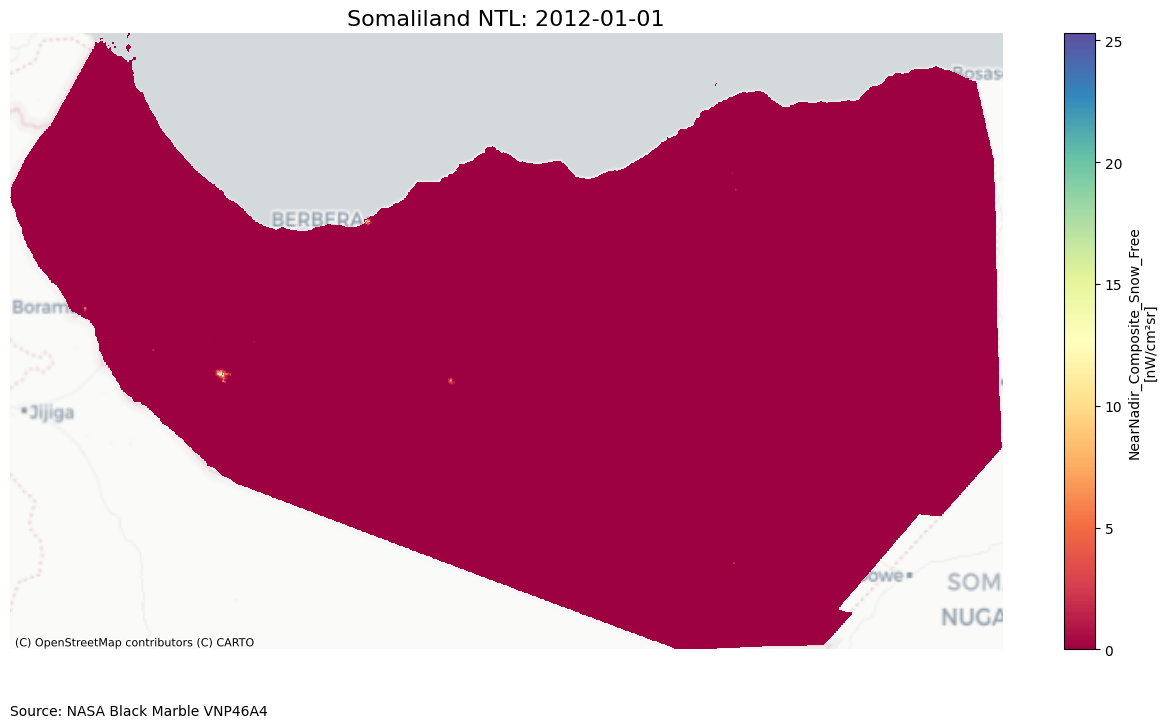

In [124]:
plot_NASA_NTL(SL_expanded, somaliland_shp_expanded, date = "2012-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False)

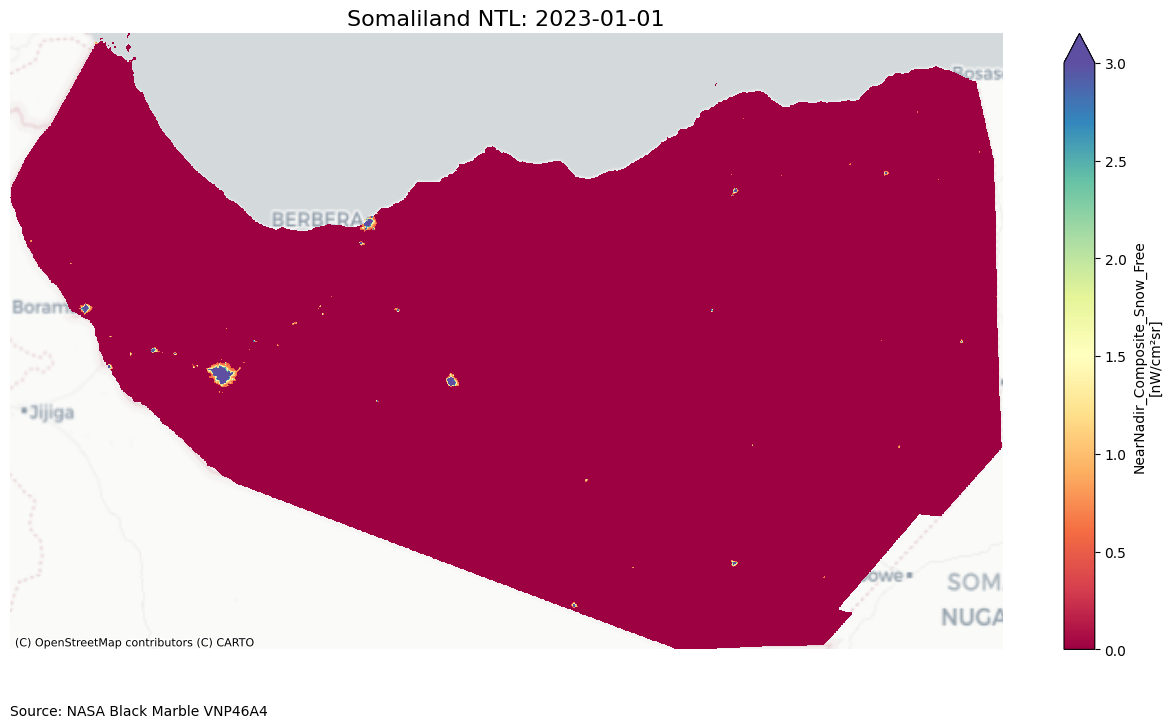

In [125]:
plot_NASA_NTL(SL_expanded, somaliland_shp_expanded, date = "2023-01-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              robust = False, vmin=0, vmax=3)

Demonstrating why Annual Data has been used rather than monthly data.

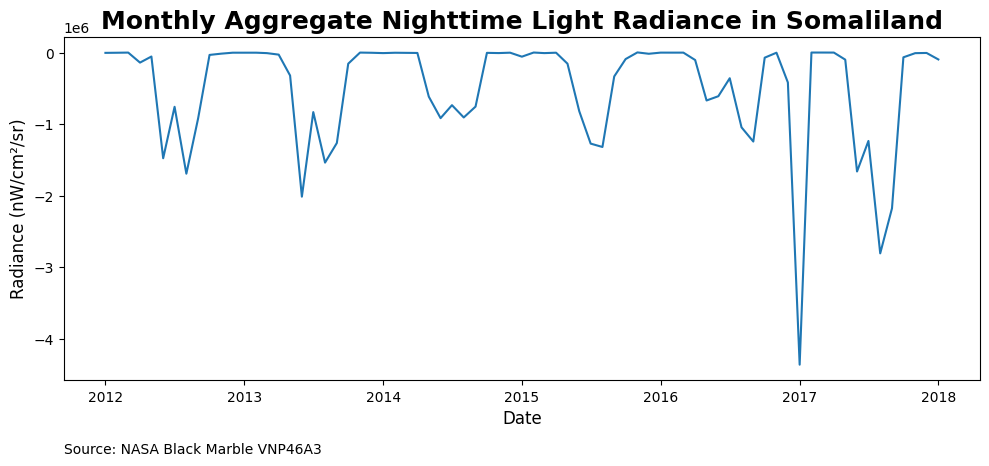

In [ ]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot NTL radiance
SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).plot(ax=ax)

ax.set_title(
    "Monthly Aggregate Nighttime Light Radiance in Somaliland", fontsize=18, weight="bold"
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Radiance (nW/cm²/sr)", fontsize=12)
ax.text(
    0,
    -0.2,
    "Source: NASA Black Marble VNP46A3",
    ha="left",
    va="center",
    transform=ax.transAxes,
    fontsize=10,
    color="black",
    weight="normal",
)

fig.tight_layout()
plt.show()

In [126]:
#Examining min values shows that fill values of -999.9 are present in the monthly data. 
print(SL_month["NearNadir_Composite_Snow_Free"].min())
print(SL_month["NearNadir_Composite_Snow_Free"].max())

<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(-999.90002441)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref
<xarray.DataArray 'NearNadir_Composite_Snow_Free' ()> Size: 8B
array(37.45820999)
Attributes:
    units:         nW/cm²sr
    long_name:     NearNadir_Composite_Snow_Free
    grid_mapping:  spatial_ref


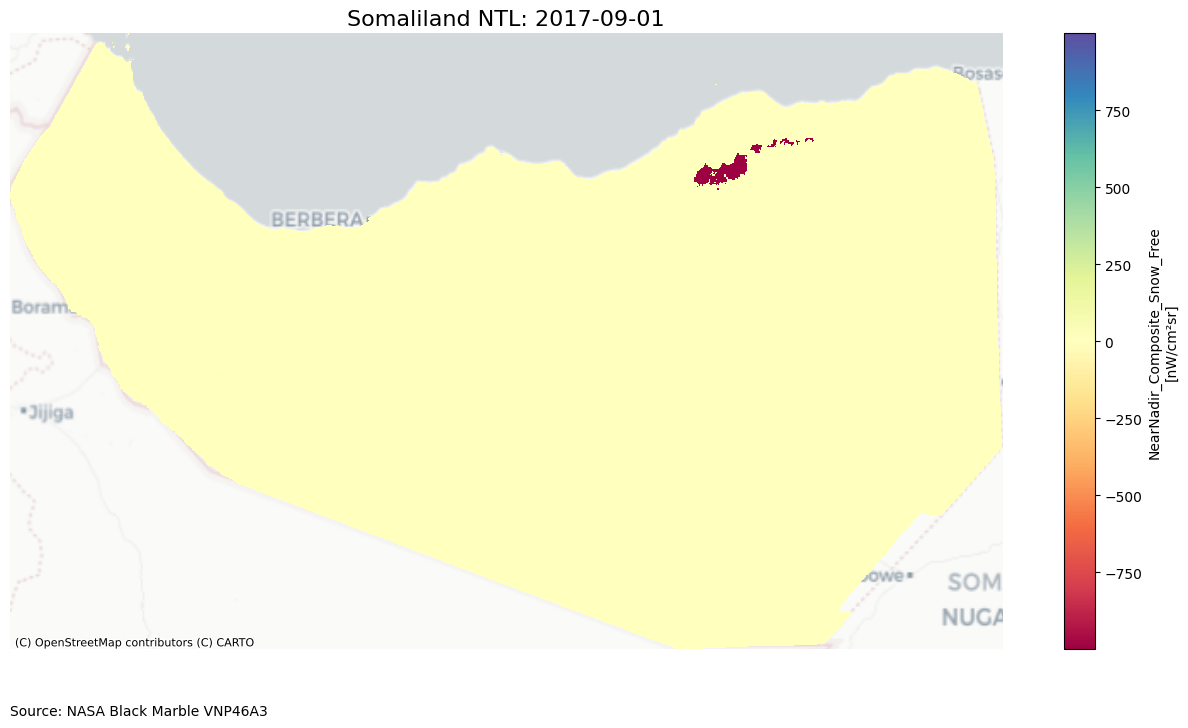

In [ ]:
plot_NASA_NTL(SL_month, somaliland_shp, date = "2017-09-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

In [127]:
#A large amount of fill values are present in the monthly data. Calculating the number of fill values per month.
month_total_pixels = []
month_filled = []
for i in SL_month.time.to_index():
    month_total_pixels.append(round((SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).count().item(), 1))
    month_filled.append((SL_month["NearNadir_Composite_Snow_Free"].sel(time=i) == SL_month["NearNadir_Composite_Snow_Free"].min()).sum().item())

df = pd.DataFrame({
    "time": list(SL_month.time.values),
    "month_total_pixels": month_total_pixels,
    "month_filled": month_filled,
})

df

,time,month_total_pixels,month_filled
0,2012-01-01,807889,2
1,2012-02-01,807889,1
2,2012-03-01,807889,0
3,2012-04-01,807889,139
4,2012-05-01,807889,57
...,...,...,...
68,2017-09-01,807889,2179
69,2017-10-01,807889,66
70,2017-11-01,807889,11
71,2017-12-01,807889,5


In [128]:
#Even removing the fill values of -999.9, there is a massive variation in total radiance in the monthly data.
clean_SL_month = xr.where(
    SL_month < -999, 
    0, # Assigning 0 for filled values (value of -999.9).
    SL_month 
)


month_total_pixels = []
month_non_zero_pixels = []
month_radiance = []
for i in SL_month.time.to_index():
    month_total_pixels.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).count().item(), 1))
    month_non_zero_pixels.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i) > 0).sum().item(), 1))
    month_radiance.append(round((clean_SL_month["NearNadir_Composite_Snow_Free"].sel(time=i)).sum().item(), 1))


df = pd.DataFrame({
    "time": list(SL_month.time.values),
    "month_total_pixels": month_total_pixels,
    "month_non_zero_pixels": month_non_zero_pixels,
    "month_radiance": month_radiance,
})

df


,time,month_total_pixels,month_non_zero_pixels,month_radiance
0,2012-01-01,807889,638,1465.9
1,2012-02-01,807889,1183,2163.4
2,2012-03-01,807889,2937,3345.7
3,2012-04-01,807889,1623,2239.8
4,2012-05-01,807889,5880,5204.3
...,...,...,...,...
68,2017-09-01,807889,1556,2911.4
69,2017-10-01,807889,1323,3223.9
70,2017-11-01,807889,6134,6286.8
71,2017-12-01,807889,932,3115.2


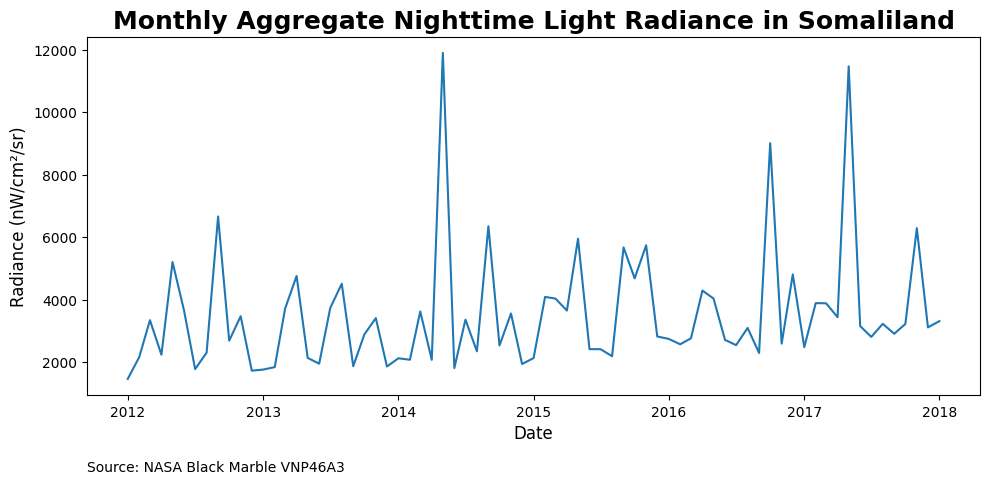

In [129]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Plot NTL radiance
clean_SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]).plot(ax=ax)

ax.set_title(
    "Monthly Aggregate Nighttime Light Radiance in Somaliland", fontsize=18, weight="bold"
)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Radiance (nW/cm²/sr)", fontsize=12)
ax.text(
    0,
    -0.2,
    "Source: NASA Black Marble VNP46A3",
    ha="left",
    va="center",
    transform=ax.transAxes,
    fontsize=10,
    color="black",
    weight="normal",
)

fig.tight_layout()
plt.show()

In [130]:
#Selecting the peak months with radiance above 11,000 nW/cm²/sr to understand drivers of variation. 
clean_SL_month.sel(time=clean_SL_month["NearNadir_Composite_Snow_Free"].sum(dim=["x", "y"]) > 11000).time.to_index()

DatetimeIndex(['2014-05-01', '2017-05-01'], dtype='datetime64[ns]', name='time', freq=None)

The graphs below show how there are a large number pixels with much higher values in the Sanaag region. 

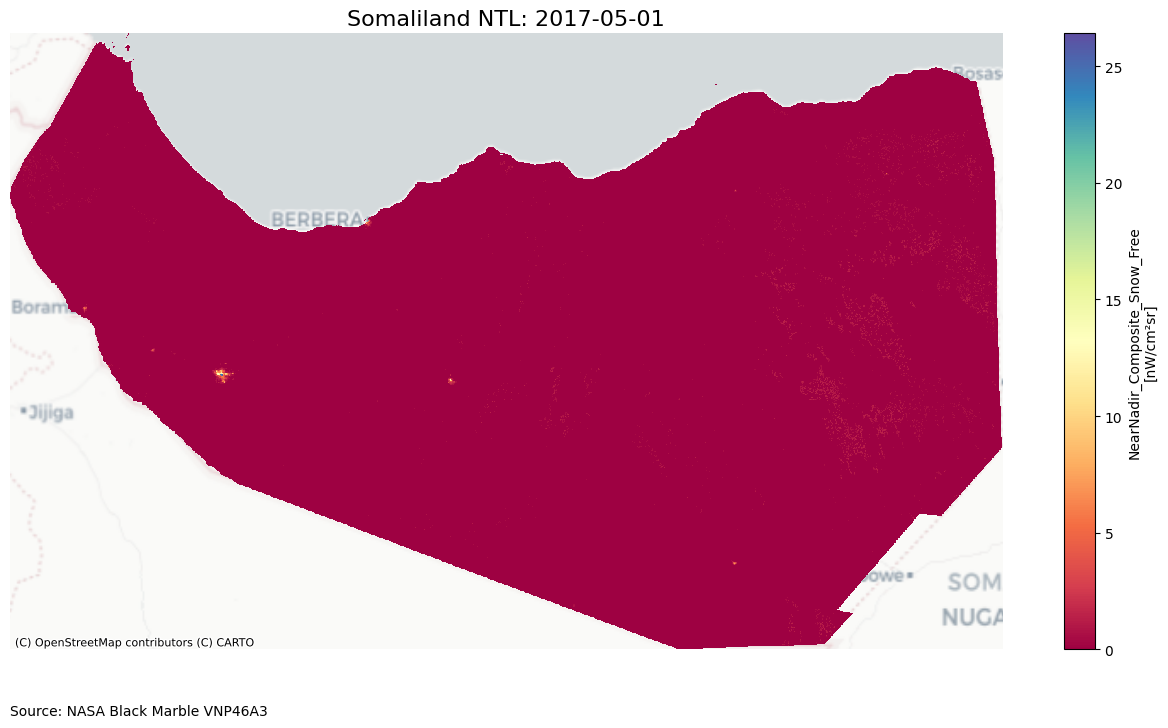

In [131]:
plot_NASA_NTL(clean_SL_month, somaliland_shp, date = "2017-05-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

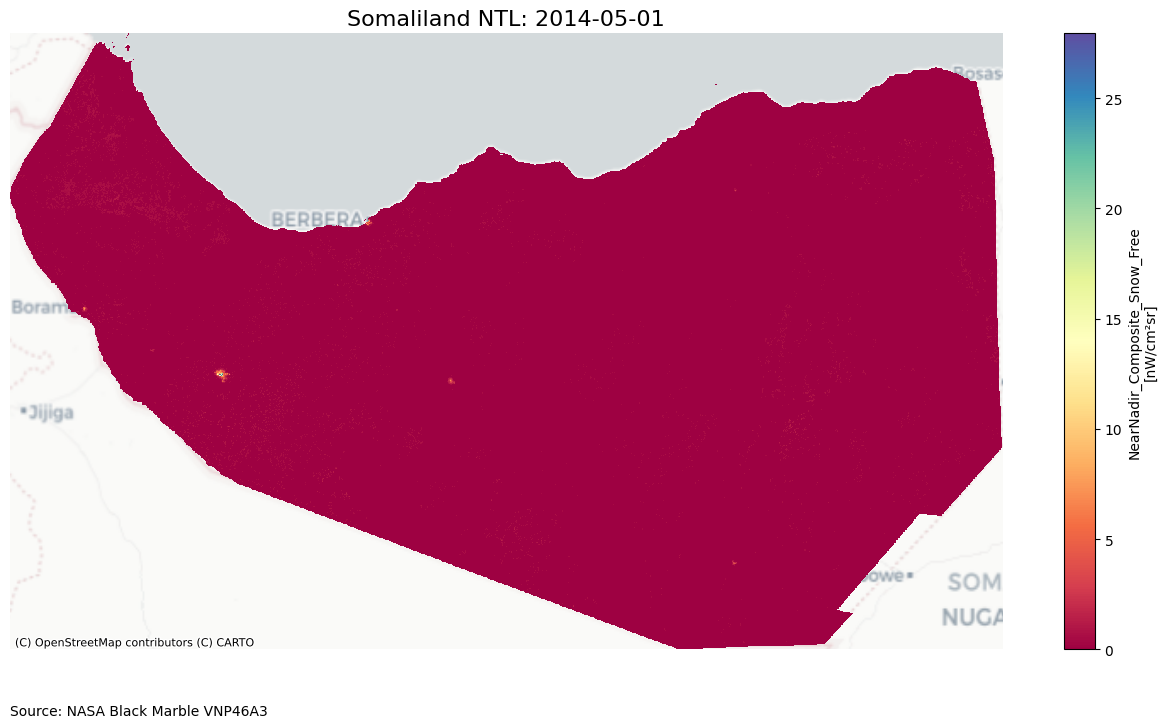

In [132]:
plot_NASA_NTL(clean_SL_month, somaliland_shp, date = "2014-05-01", 
              variable = "NearNadir_Composite_Snow_Free",
              title_prefix = "Somaliland NTL",
              source="VNP46A3",
              robust = False)

The graph below shows the quality of the observations per pixel. This potentially explains the variation. 
We also show the number of observations per pixel which demonstrates why there is lower quality in the Sanaag area. 

00 Good-quality The number of observations used for the
composite is larger than 3
01 Poor-quality The number of observations used for the
composite is less than or equal to 3
02 Gap filled Gap filled NTL based on historical data
255 Fill value Fill value


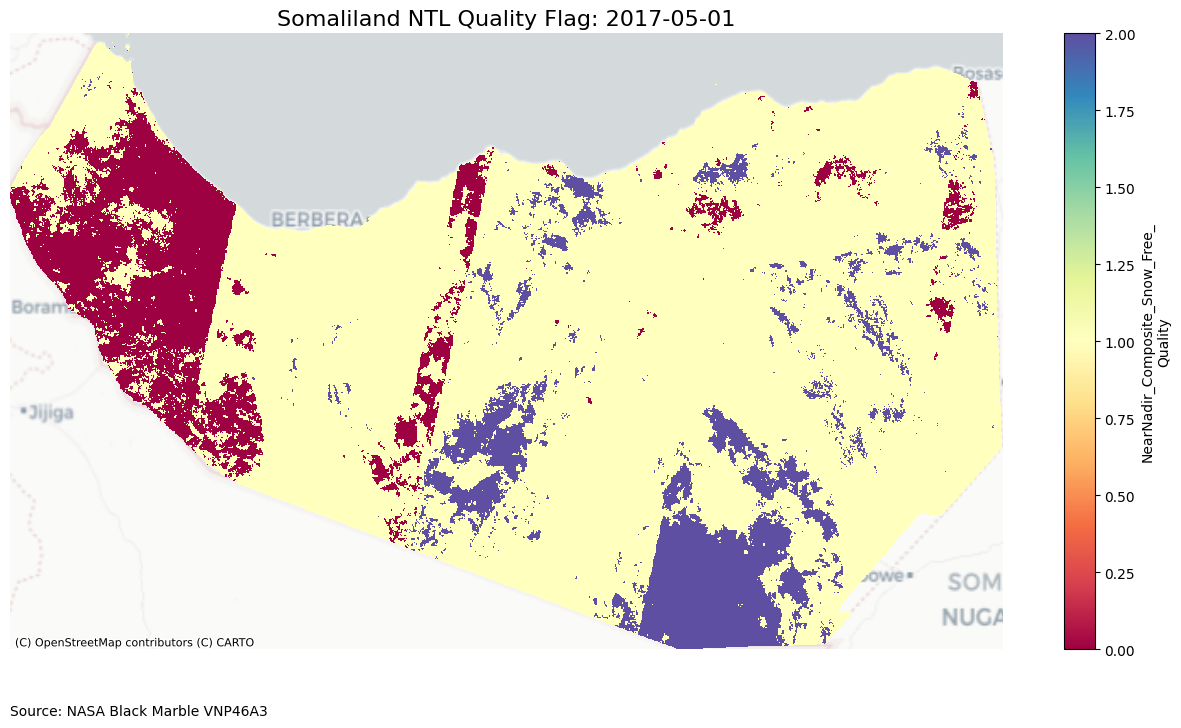

In [134]:
plot_NASA_NTL(SL_qual, somaliland_shp, date = "2017-05-01", 
              variable = "NearNadir_Composite_Snow_Free_Quality", robust=False, source="VNP46A3", title_prefix="Somaliland NTL Quality Flag")

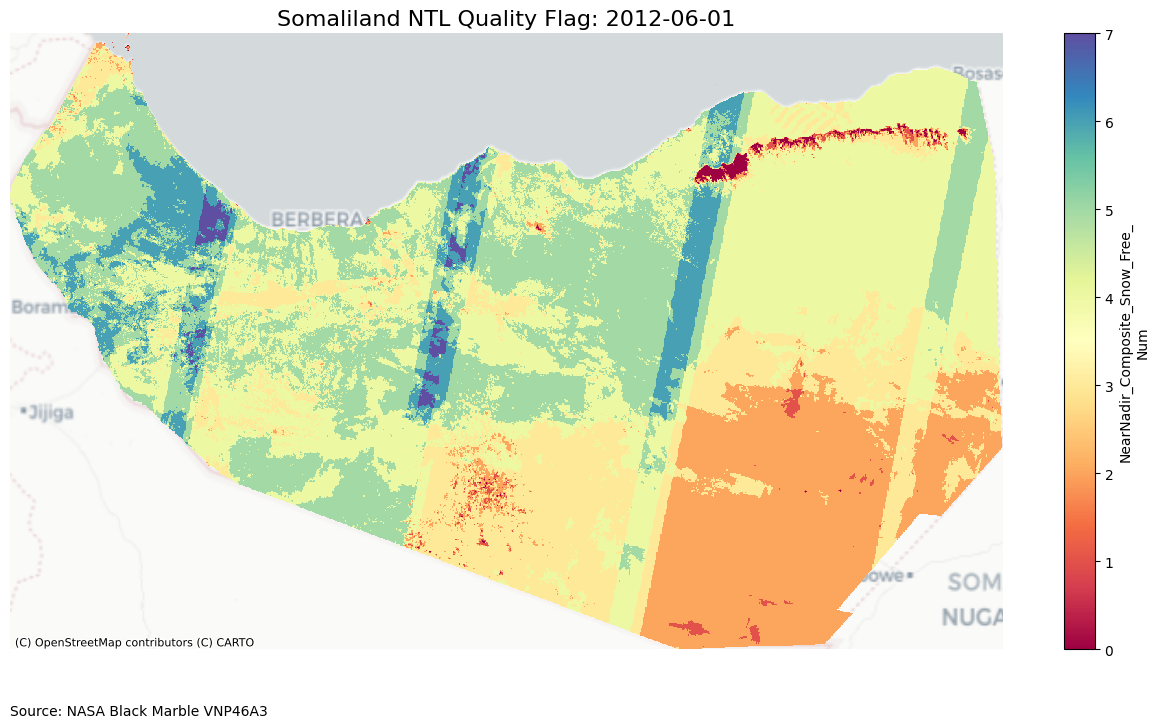

In [135]:
plot_NASA_NTL(SL_num, somaliland_shp, date = "2012-06-01", 
              variable = "NearNadir_Composite_Snow_Free_Num", robust=False, source="VNP46A3", title_prefix="Somaliland NTL Quality Flag")


In [20]:
values2012 = SL_expanded["NearNadir_Composite_Snow_Free"].sel(time="2012-01-01").values.flatten()
values2012 = values2012[~np.isnan(values2012)]
values2012 = values2012[values2012 > 0]

values2023 = SL_expanded["NearNadir_Composite_Snow_Free"].sel(time="2023-01-01").values.flatten()
values2023 = values2023[~np.isnan(values2023)]
values2023 = values2023[values2023 > 0]

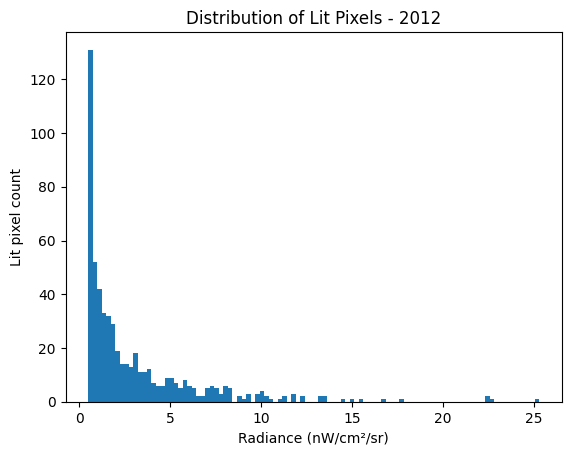

In [21]:
plt.hist(values2012, bins=100)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Distribution of Lit Pixels - 2012")
plt.show()

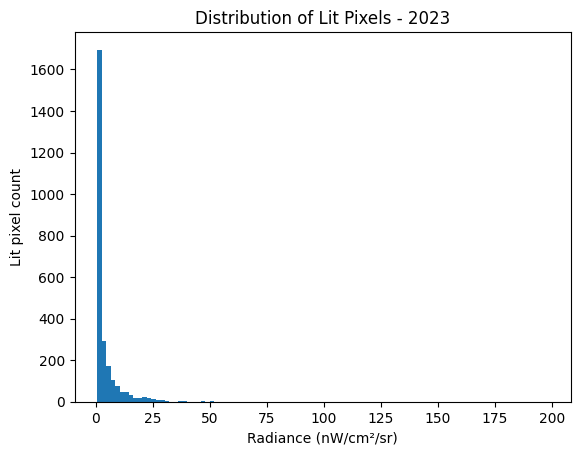

In [22]:
plt.hist(values2023, bins=100)
plt.xlabel("Radiance (nW/cm²/sr)")
plt.ylabel("Lit pixel count")
plt.title("Distribution of Lit Pixels - 2023")
plt.show()

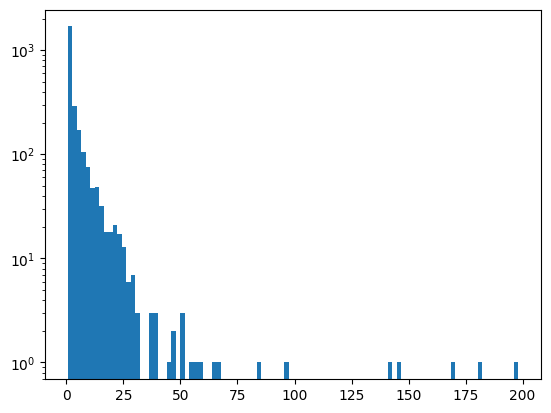

In [24]:
plt.hist(values2023, bins=100, log=True)
plt.show()